# Fixation mRNN 100K Derivative/Curvature Loss Checks

Train or load 100K-iteration fits using PC reconstruction plus asymmetric temporal derivative/curvature loss weights. Each model setting has its own fit, loss, PC reconstruction, and backprojected firing-rate section.

## 1. Setup

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    load_fixation_mrnn_config,
    make_targets,
    pc_reconstructed_firing_rate_accuracy,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    resolve_fixation_mrnn_output_root,
    settings_from_config,
    train_fixation_mrnn_scratch,
)

plt.rcParams.update({"figure.dpi": 140, "axes.spines.top": False, "axes.spines.right": False})

## 2. Shared Model Settings and Helpers

In [ ]:
cfg = load_fixation_mrnn_config(repo_root / "configs/ephys_fixation_mrnn.yaml")

base_settings = settings_from_config(
    cfg,
    overrides={
        "target_mode": "region_pcs",
        "temporal_basis_count": 0,
        "hidden_units": 50,
        "lr": 1e-3,
        "epochs": 100_000,
        "initialization_mode": "single",
        "device": "auto",
        "correlation_loss_scale": 0.0,
        "variance_loss_scale": 0.0,
        "fr_reconstruction_loss_scale": 0.0,
        "fr_temporal_derivative_loss_scale": 0.0,
        "fr_temporal_curvature_loss_scale": 0.0,
    },
)

loss_variants = {
    "pc_derivative_w3_curvature_w5": dict(
        temporal_derivative_loss_scale=3.0,
        temporal_curvature_loss_scale=5.0,
    ),
    "pc_derivative_w5_curvature_w3": dict(
        temporal_derivative_loss_scale=5.0,
        temporal_curvature_loss_scale=3.0,
    ),
    "pc_derivative_w5_curvature_w5": dict(
        temporal_derivative_loss_scale=5.0,
        temporal_curvature_loss_scale=5.0,
    ),
}

run_mode = "load"  # use "train" to fit missing variants
overwrite = False
scratch_prefix = "loss_necessity_pc_deriv_curv_50u_100k"
output_root = resolve_fixation_mrnn_output_root(base_settings) / "scratch"
targets = make_targets(base_settings)
timeline = np.asarray(targets.timeline_s, dtype=float)

pd.DataFrame(
    [
        {
            "loss_variant": label,
            "hidden_units_per_region": base_settings.hidden_units,
            "lr": base_settings.lr,
            "epochs": base_settings.epochs,
            **overrides,
            "correlation_loss_scale": base_settings.correlation_loss_scale,
            "variance_loss_scale": base_settings.variance_loss_scale,
            "fr_reconstruction_loss_scale": base_settings.fr_reconstruction_loss_scale,
            "fr_temporal_derivative_loss_scale": base_settings.fr_temporal_derivative_loss_scale,
            "fr_temporal_curvature_loss_scale": base_settings.fr_temporal_curvature_loss_scale,
        }
        for label, overrides in loss_variants.items()
    ]
)

,loss_variant,hidden_units_per_region,lr,epochs,temporal_derivative_loss_scale,temporal_curvature_loss_scale,correlation_loss_scale,variance_loss_scale,fr_reconstruction_loss_scale,fr_temporal_derivative_loss_scale,fr_temporal_curvature_loss_scale
0,pc_derivative_w3_curvature_w5,50,0.001,100000,3.0,5.0,0.0,0.0,0.0,0.0,0.0
1,pc_derivative_w5_curvature_w3,50,0.001,100000,5.0,3.0,0.0,0.0,0.0,0.0,0.0
2,pc_derivative_w5_curvature_w5,50,0.001,100000,5.0,5.0,0.0,0.0,0.0,0.0,0.0


In [3]:
def fit_or_load_loss_variant(label):
    overrides = loss_variants[label]
    settings = replace(base_settings, **overrides)
    scratch_id = f"{scratch_prefix}_{label}"
    run_dir = output_root / scratch_id
    checkpoint_path = run_dir / "checkpoint_final.pth"
    if run_mode == "train" or not checkpoint_path.exists():
        result = train_fixation_mrnn_scratch(settings, scratch_id=scratch_id, overwrite=overwrite)
        run_dir = Path(result["run_dir"])
    history = pd.read_csv(run_dir / "history.csv")
    replay = replay_fixation_mrnn_run(run_dir, device=settings.device)
    return {"label": label, "settings": settings, "run_dir": run_dir, "history": history, "replay": replay}


def plot_nonzero_loss_trajectory(bundle):
    settings = bundle["settings"]
    history = bundle["history"]
    weighted_columns = {
        "reconstruction_loss": 1.0,
        "temporal_derivative_loss": settings.temporal_derivative_loss_scale,
        "temporal_curvature_loss": settings.temporal_curvature_loss_scale,
        "correlation_loss": settings.correlation_loss_scale,
        "variance_loss": settings.variance_loss_scale,
        "fr_reconstruction_loss": settings.fr_reconstruction_loss_scale,
        "fr_temporal_derivative_loss": settings.fr_temporal_derivative_loss_scale,
        "fr_temporal_curvature_loss": settings.fr_temporal_curvature_loss_scale,
    }
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    for column, weight in weighted_columns.items():
        if float(weight) == 0.0 or column not in history.columns:
            continue
        ax.plot(history["iteration"], history[column] * float(weight), linewidth=1.0, label=f"{column} x {weight:g}")
    ax.plot(history["iteration"], history["loss"], color="black", linewidth=1.5, label="total loss")
    ax.set(title=bundle["label"], xlabel="iteration", ylabel="weighted loss")
    ax.set_yscale("log")
    ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    return fig, ax


def final_fit_quality(bundle):
    history = bundle["history"]
    replay = bundle["replay"]
    final_losses = pd.DataFrame(
        [
            {
                "loss_variant": bundle["label"],
                "run_dir": str(bundle["run_dir"]),
                "iterations": int(history["iteration"].iloc[-1]),
                "loss": float(history["loss"].iloc[-1]),
                "reconstruction_loss": float(history["reconstruction_loss"].iloc[-1]),
                "temporal_derivative_loss": float(history["temporal_derivative_loss"].iloc[-1]),
                "temporal_curvature_loss": float(history["temporal_curvature_loss"].iloc[-1]),
            }
        ]
    )
    metrics = pd.concat(
        [
            reconstruction_accuracy(replay).assign(metric_space="region_pcs", loss_variant=bundle["label"]),
            pc_reconstructed_firing_rate_accuracy(replay).assign(metric_space="backprojected_fr", loss_variant=bundle["label"]),
        ],
        ignore_index=True,
    )
    summary = (
        metrics.groupby(["loss_variant", "metric_space", "region"], as_index=False)
        .agg(mean_mse=("mse", "mean"), mean_mae=("mae", "mean"), mean_r2=("r2", "mean"), mean_corr=("correlation", "mean"))
        .sort_values(["metric_space", "region"])
    )
    return final_losses, summary, metrics


def plot_random_region_pc_reconstruction(bundle, n_pcs_to_plot=6):
    rng = np.random.default_rng()
    region = str(rng.choice(targets.region_order))
    conditions = tuple(targets.condition_order)
    n_pcs = min(int(n_pcs_to_plot), targets.pcs_by_region[region].shape[-1])
    fig, axes = plt.subplots(n_pcs, len(conditions), figsize=(3.2 * len(conditions), 1.9 * n_pcs), sharex=True, squeeze=False)
    for pc_idx in range(n_pcs):
        for cond_col, condition in enumerate(conditions):
            ax = axes[pc_idx, cond_col]
            cond_idx = targets.condition_order.index(condition)
            ax.plot(timeline, targets.pcs_by_region[region][cond_idx, :, pc_idx], color="black", linewidth=2.0, label="target")
            yhat = bundle["replay"]["output_by_region"][region].detach().cpu().numpy()[cond_idx, :, pc_idx]
            ax.plot(timeline, yhat, color="#2f6fbb", linewidth=1.2, label=bundle["label"])
            ax.axvline(0.0, color="0.5", linewidth=0.7)
            if pc_idx == 0:
                ax.set_title(condition)
            if cond_col == 0:
                ax.set_ylabel(f"PC{pc_idx + 1}")
            if pc_idx == n_pcs - 1:
                ax.set_xlabel("time (s)")
    axes[0, -1].legend(frameon=False, fontsize=7)
    fig.suptitle(f"{bundle['label']} | region: {region}", y=1.01)
    fig.tight_layout()
    return fig, axes, region


def plot_random_region_fr_reconstruction(bundle, n_units_to_plot=6):
    rng = np.random.default_rng()
    region = str(rng.choice(targets.region_order))
    conditions = tuple(targets.condition_order)
    target_fr_by_region = targets.pc_reconstructed_raw_by_region()
    predicted_fr = backproject_replay_outputs_to_firing_rates(bundle["replay"])[region]
    n_units = target_fr_by_region[region].shape[-1]
    unit_indices = np.sort(rng.choice(n_units, size=min(int(n_units_to_plot), n_units), replace=False))
    fig, axes = plt.subplots(len(unit_indices), len(conditions), figsize=(3.2 * len(conditions), 1.9 * len(unit_indices)), sharex=True, squeeze=False)
    for row, unit_idx in enumerate(unit_indices):
        for cond_col, condition in enumerate(conditions):
            ax = axes[row, cond_col]
            cond_idx = targets.condition_order.index(condition)
            ax.plot(timeline, target_fr_by_region[region][cond_idx, :, unit_idx], color="black", linewidth=2.0, label="target")
            ax.plot(timeline, predicted_fr[cond_idx, :, unit_idx], color="#2f6fbb", linewidth=1.2, label=bundle["label"])
            ax.axvline(0.0, color="0.5", linewidth=0.7)
            if row == 0:
                ax.set_title(condition)
            if cond_col == 0:
                ax.set_ylabel(f"unit {unit_idx}")
            if row == len(unit_indices) - 1:
                ax.set_xlabel("time (s)")
    axes[0, -1].legend(frameon=False, fontsize=7)
    fig.suptitle(f"{bundle['label']} | region: {region}", y=1.01)
    fig.tight_layout()
    return fig, axes, region, unit_indices

## 3. Derivative Weight 3, Curvature Weight 5

### 3.1 Fit or Load

In [4]:
d3_c5_bundle = fit_or_load_loss_variant("pc_derivative_w3_curvature_w5")
pd.DataFrame([{"run_dir": str(d3_c5_bundle["run_dir"]), "iterations": int(d3_c5_bundle["history"]["iteration"].iloc[-1])}])

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

,run_dir,iterations
0,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000


### 3.2 Nonzero Loss Trajectory

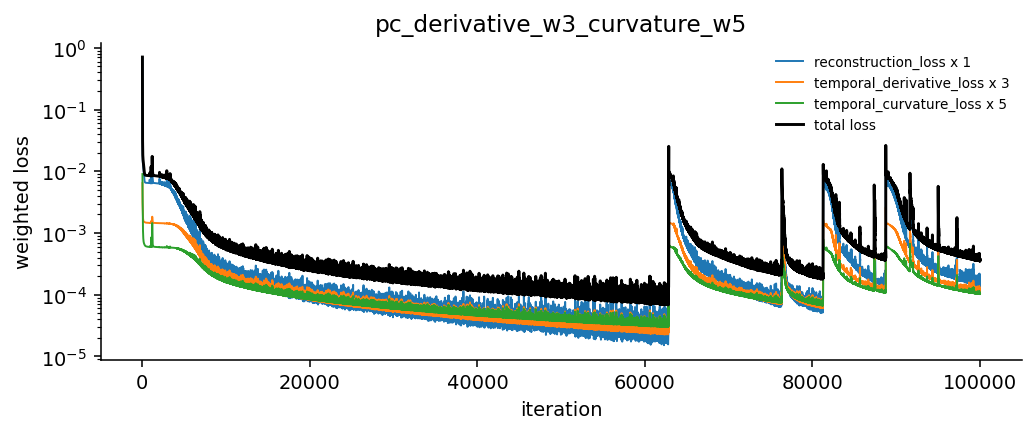

In [5]:
plot_nonzero_loss_trajectory(d3_c5_bundle);

### 3.3 Final Fit Quality

In [6]:
d3_c5_final_losses, d3_c5_fit_quality, d3_c5_metrics = final_fit_quality(d3_c5_bundle)
display(d3_c5_final_losses)
display(d3_c5_fit_quality)

,loss_variant,run_dir,iterations,loss,reconstruction_loss,temporal_derivative_loss,temporal_curvature_loss
0,pc_derivative_w3_curvature_w5,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000,0.00036,0.000142,0.000038,0.000021


,loss_variant,metric_space,region,mean_mse,mean_mae,mean_r2,mean_corr
0,pc_derivative_w3_curvature_w5,backprojected_fr,accg,0.000018,0.002708,0.999432,0.999716
1,pc_derivative_w3_curvature_w5,backprojected_fr,bla,0.000013,0.002141,0.999830,0.999915
2,pc_derivative_w3_curvature_w5,backprojected_fr,dmpfc,0.000031,0.003412,0.999459,0.999729
3,pc_derivative_w3_curvature_w5,backprojected_fr,ofc,0.000031,0.003341,0.999661,0.999830
4,pc_derivative_w3_curvature_w5,region_pcs,accg,0.000104,0.007343,0.966227,0.982795
5,pc_derivative_w3_curvature_w5,region_pcs,bla,0.000168,0.008978,0.989275,0.994642
6,pc_derivative_w3_curvature_w5,region_pcs,dmpfc,0.000138,0.008202,0.971768,0.985640
7,pc_derivative_w3_curvature_w5,region_pcs,ofc,0.000177,0.009275,0.981249,0.990526


### 3.4 Random-Region PC Reconstruction

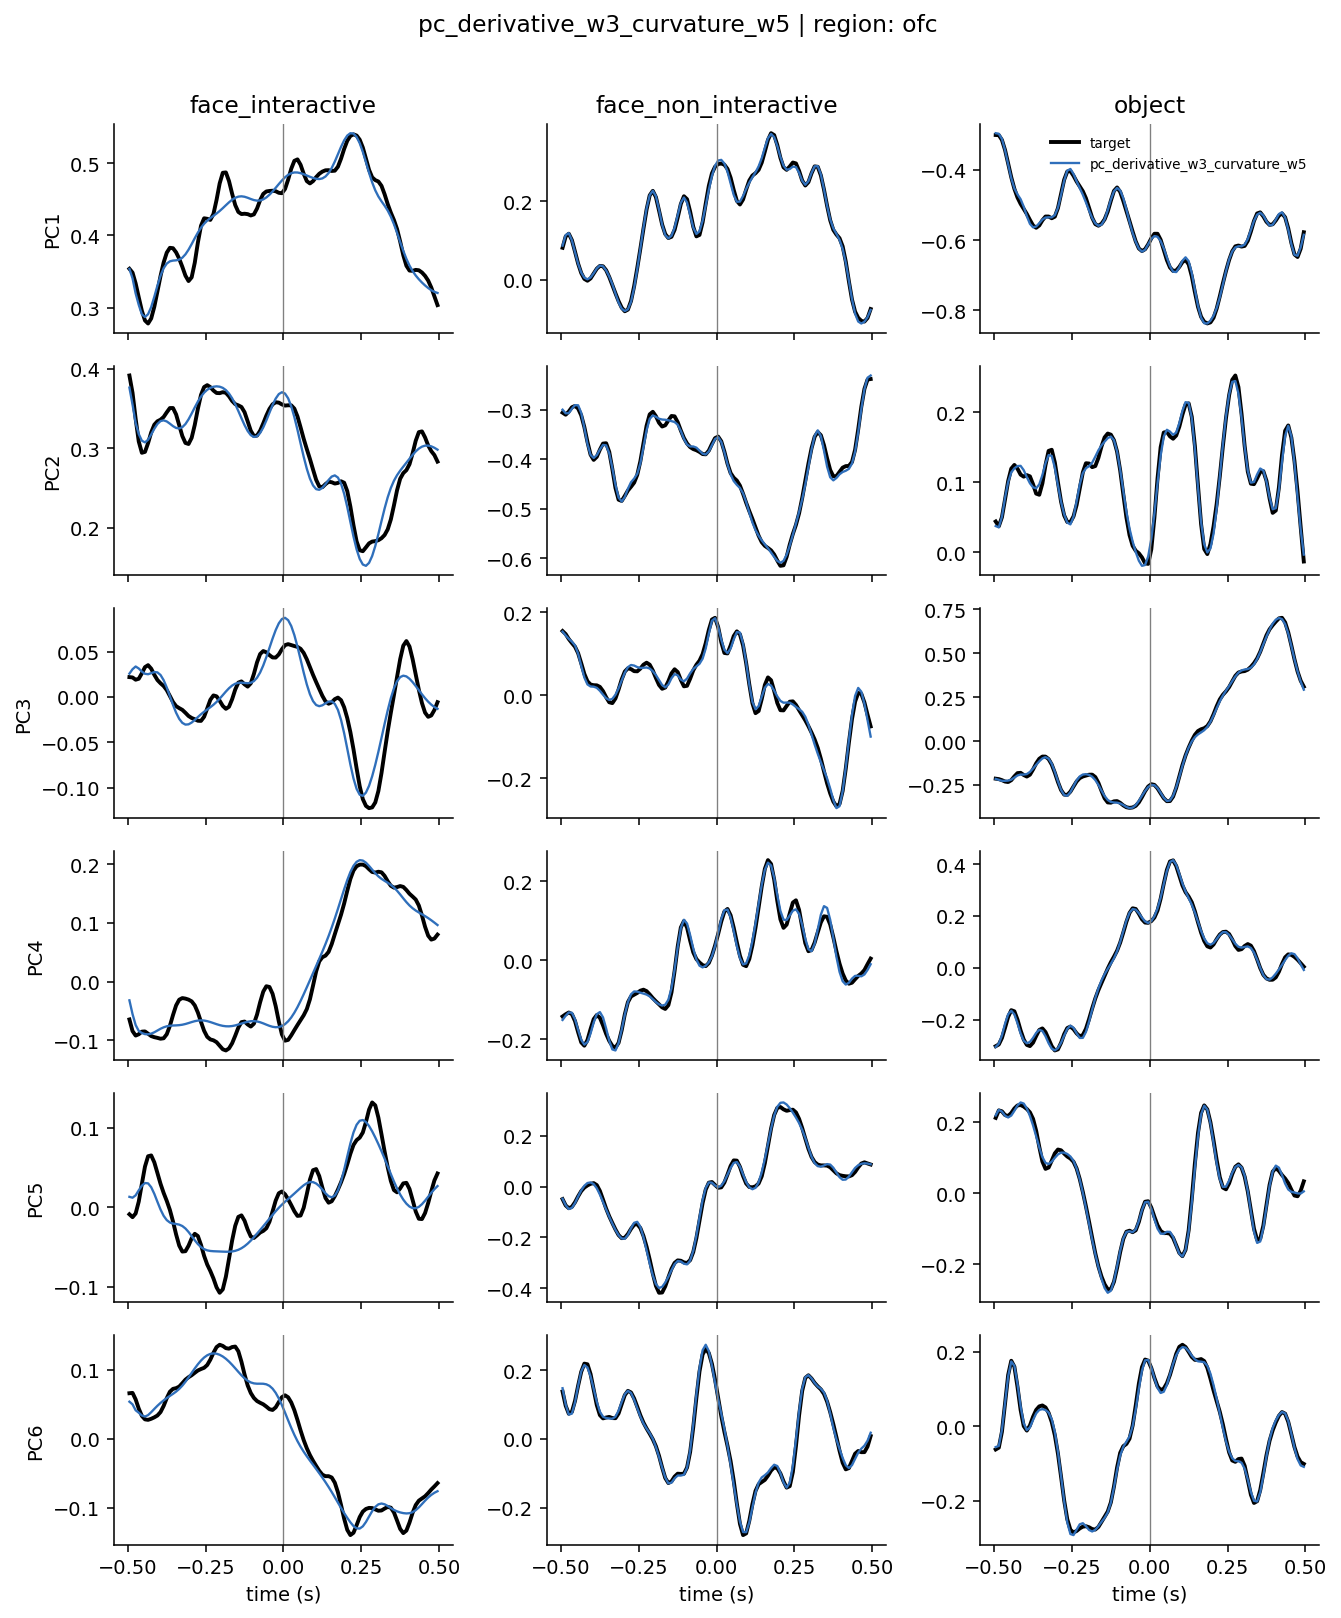

In [7]:
plot_random_region_pc_reconstruction(d3_c5_bundle);

### 3.5 Random-Region Backprojected Firing Rates

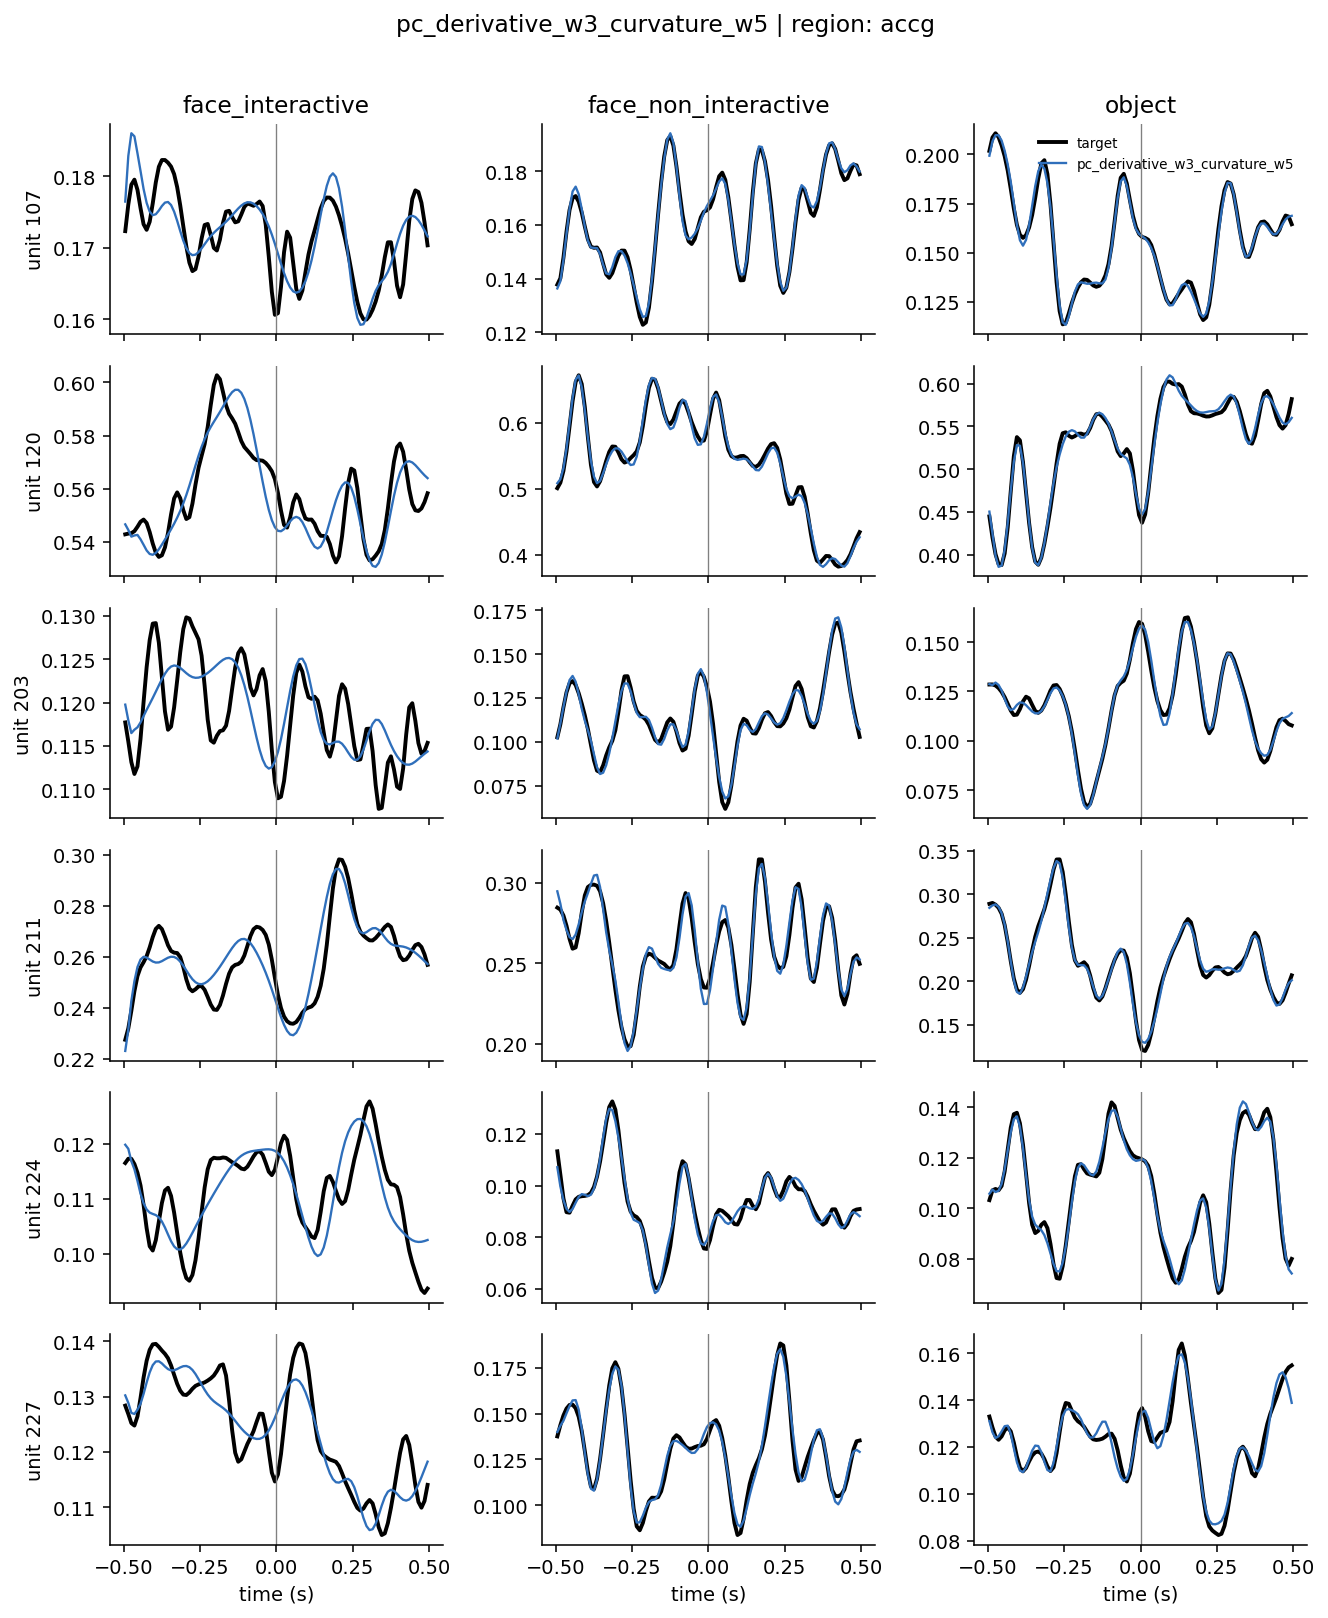

In [8]:
plot_random_region_fr_reconstruction(d3_c5_bundle);

## 4. Derivative Weight 5, Curvature Weight 3

### 4.1 Fit or Load

In [9]:
d5_c3_bundle = fit_or_load_loss_variant("pc_derivative_w5_curvature_w3")
pd.DataFrame([{"run_dir": str(d5_c3_bundle["run_dir"]), "iterations": int(d5_c3_bundle["history"]["iteration"].iloc[-1])}])

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

,run_dir,iterations
0,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000


### 4.2 Nonzero Loss Trajectory

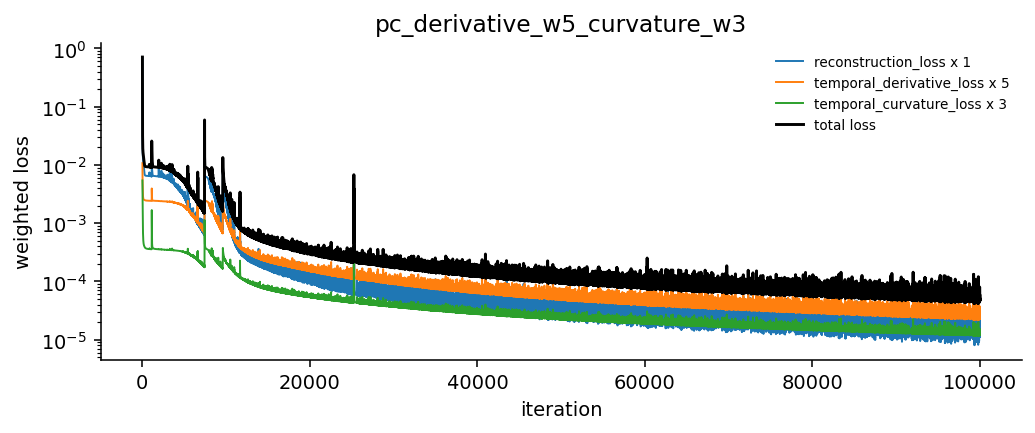

In [10]:
plot_nonzero_loss_trajectory(d5_c3_bundle);

### 4.3 Final Fit Quality

In [11]:
d5_c3_final_losses, d5_c3_fit_quality, d5_c3_metrics = final_fit_quality(d5_c3_bundle)
display(d5_c3_final_losses)
display(d5_c3_fit_quality)

,loss_variant,run_dir,iterations,loss,reconstruction_loss,temporal_derivative_loss,temporal_curvature_loss
0,pc_derivative_w5_curvature_w3,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000,0.000057,0.000015,0.000006,0.000004


,loss_variant,metric_space,region,mean_mse,mean_mae,mean_r2,mean_corr
0,pc_derivative_w5_curvature_w3,backprojected_fr,accg,0.000002,0.001051,0.999930,0.999965
1,pc_derivative_w5_curvature_w3,backprojected_fr,bla,0.000002,0.000777,0.999980,0.999990
2,pc_derivative_w5_curvature_w3,backprojected_fr,dmpfc,0.000004,0.001352,0.999935,0.999967
3,pc_derivative_w5_curvature_w3,backprojected_fr,ofc,0.000003,0.001150,0.999966,0.999983
4,pc_derivative_w5_curvature_w3,region_pcs,accg,0.000012,0.002723,0.996823,0.998412
5,pc_derivative_w5_curvature_w3,region_pcs,bla,0.000020,0.003220,0.999181,0.999592
6,pc_derivative_w5_curvature_w3,region_pcs,dmpfc,0.000016,0.003116,0.997334,0.998669
7,pc_derivative_w5_curvature_w3,region_pcs,ofc,0.000017,0.003097,0.998637,0.999321


### 4.4 Random-Region PC Reconstruction

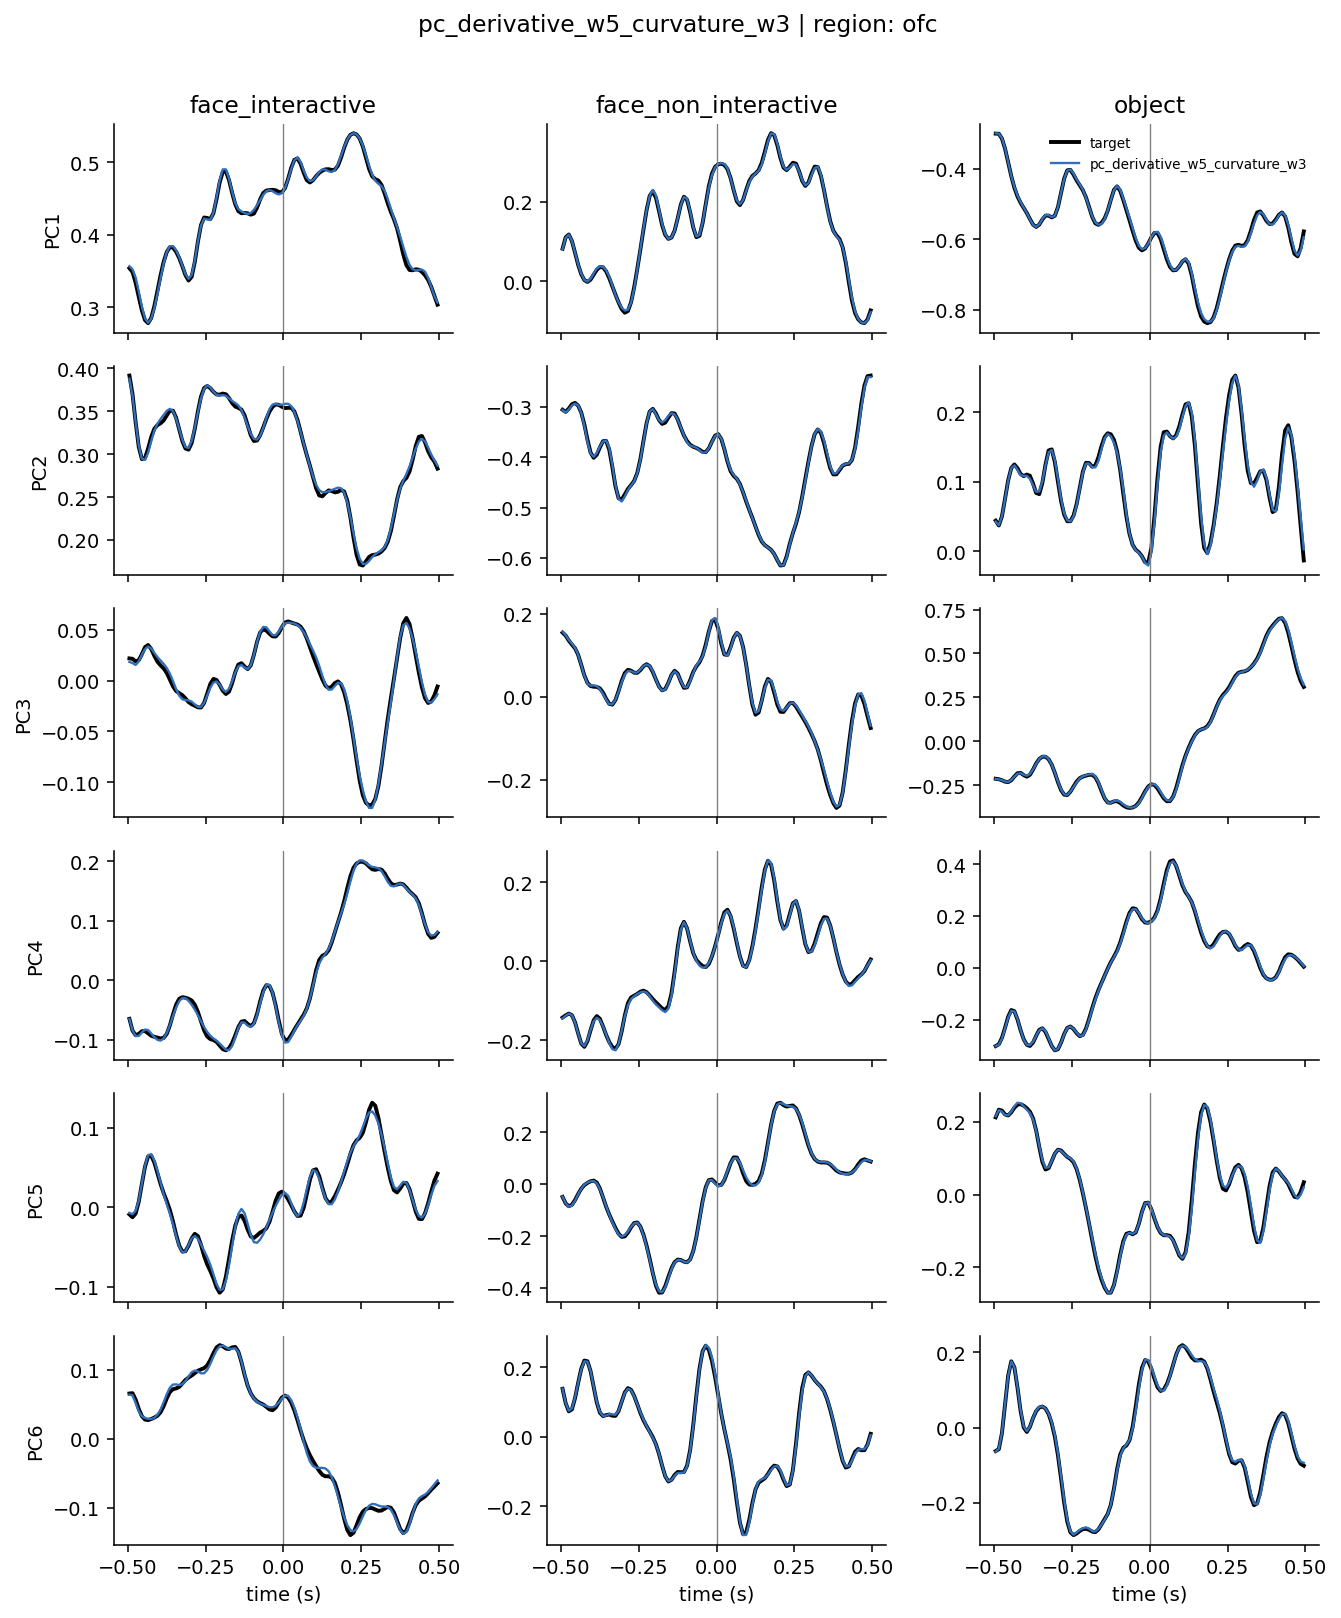

In [12]:
plot_random_region_pc_reconstruction(d5_c3_bundle);

### 4.5 Random-Region Backprojected Firing Rates

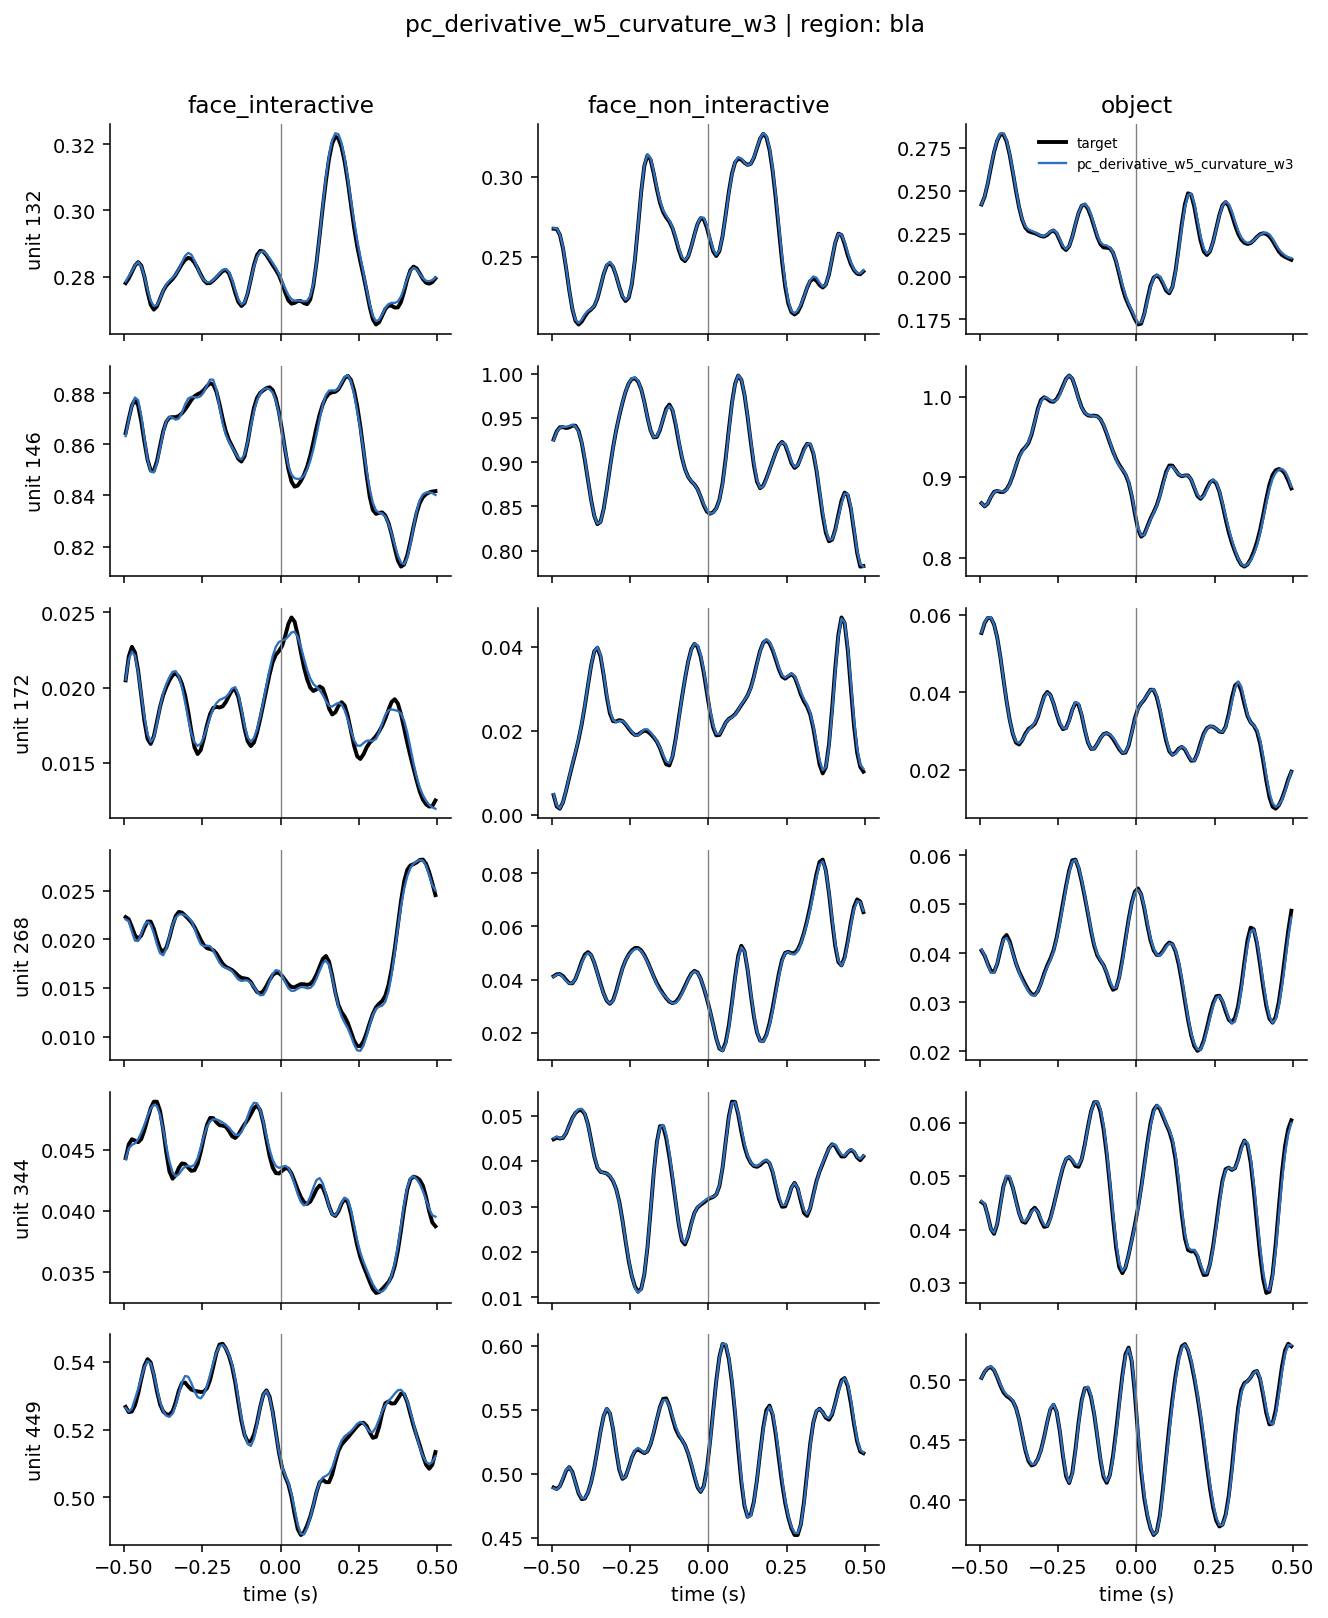

In [13]:
plot_random_region_fr_reconstruction(d5_c3_bundle);

## 5. Derivative Weight 5, Curvature Weight 5

### 5.1 Fit or Load

In [14]:
d5_c5_bundle = fit_or_load_loss_variant("pc_derivative_w5_curvature_w5")
pd.DataFrame([{"run_dir": str(d5_c5_bundle["run_dir"]), "iterations": int(d5_c5_bundle["history"]["iteration"].iloc[-1])}])

region_pcs seed=211382628:   0%|          | 0/100000 [00:00<?, ?iter/s]

,run_dir,iterations
0,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000


### 5.2 Nonzero Loss Trajectory

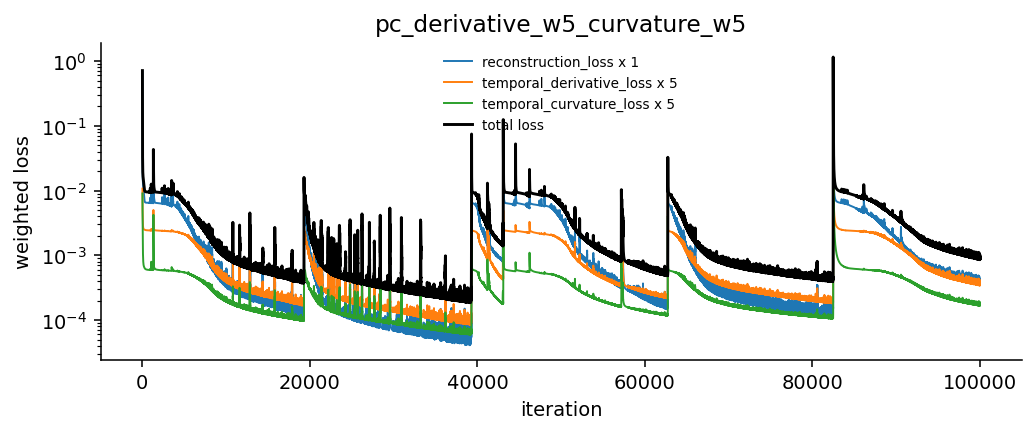

In [15]:
plot_nonzero_loss_trajectory(d5_c5_bundle);

### 5.3 Final Fit Quality

In [16]:
d5_c5_final_losses, d5_c5_fit_quality, d5_c5_metrics = final_fit_quality(d5_c5_bundle)
display(d5_c5_final_losses)
display(d5_c5_fit_quality)

,loss_variant,run_dir,iterations,loss,reconstruction_loss,temporal_derivative_loss,temporal_curvature_loss
0,pc_derivative_w5_curvature_w5,/gpfs/milgram/pi/chang/pg496/repositories/loca...,100000,0.000921,0.000382,0.000073,0.000035


,loss_variant,metric_space,region,mean_mse,mean_mae,mean_r2,mean_corr
0,pc_derivative_w5_curvature_w5,backprojected_fr,accg,0.000038,0.003887,0.998817,0.999409
1,pc_derivative_w5_curvature_w5,backprojected_fr,bla,0.000046,0.003853,0.999396,0.999698
2,pc_derivative_w5_curvature_w5,backprojected_fr,dmpfc,0.000056,0.004779,0.999012,0.999507
3,pc_derivative_w5_curvature_w5,backprojected_fr,ofc,0.000073,0.005165,0.999197,0.999599
4,pc_derivative_w5_curvature_w5,region_pcs,accg,0.000216,0.010699,0.931723,0.964500
5,pc_derivative_w5_curvature_w5,region_pcs,bla,0.000594,0.016579,0.962674,0.980938
6,pc_derivative_w5_curvature_w5,region_pcs,dmpfc,0.000251,0.011617,0.952656,0.975720
7,pc_derivative_w5_curvature_w5,region_pcs,ofc,0.000417,0.014645,0.956900,0.977961


### 5.4 Random-Region PC Reconstruction

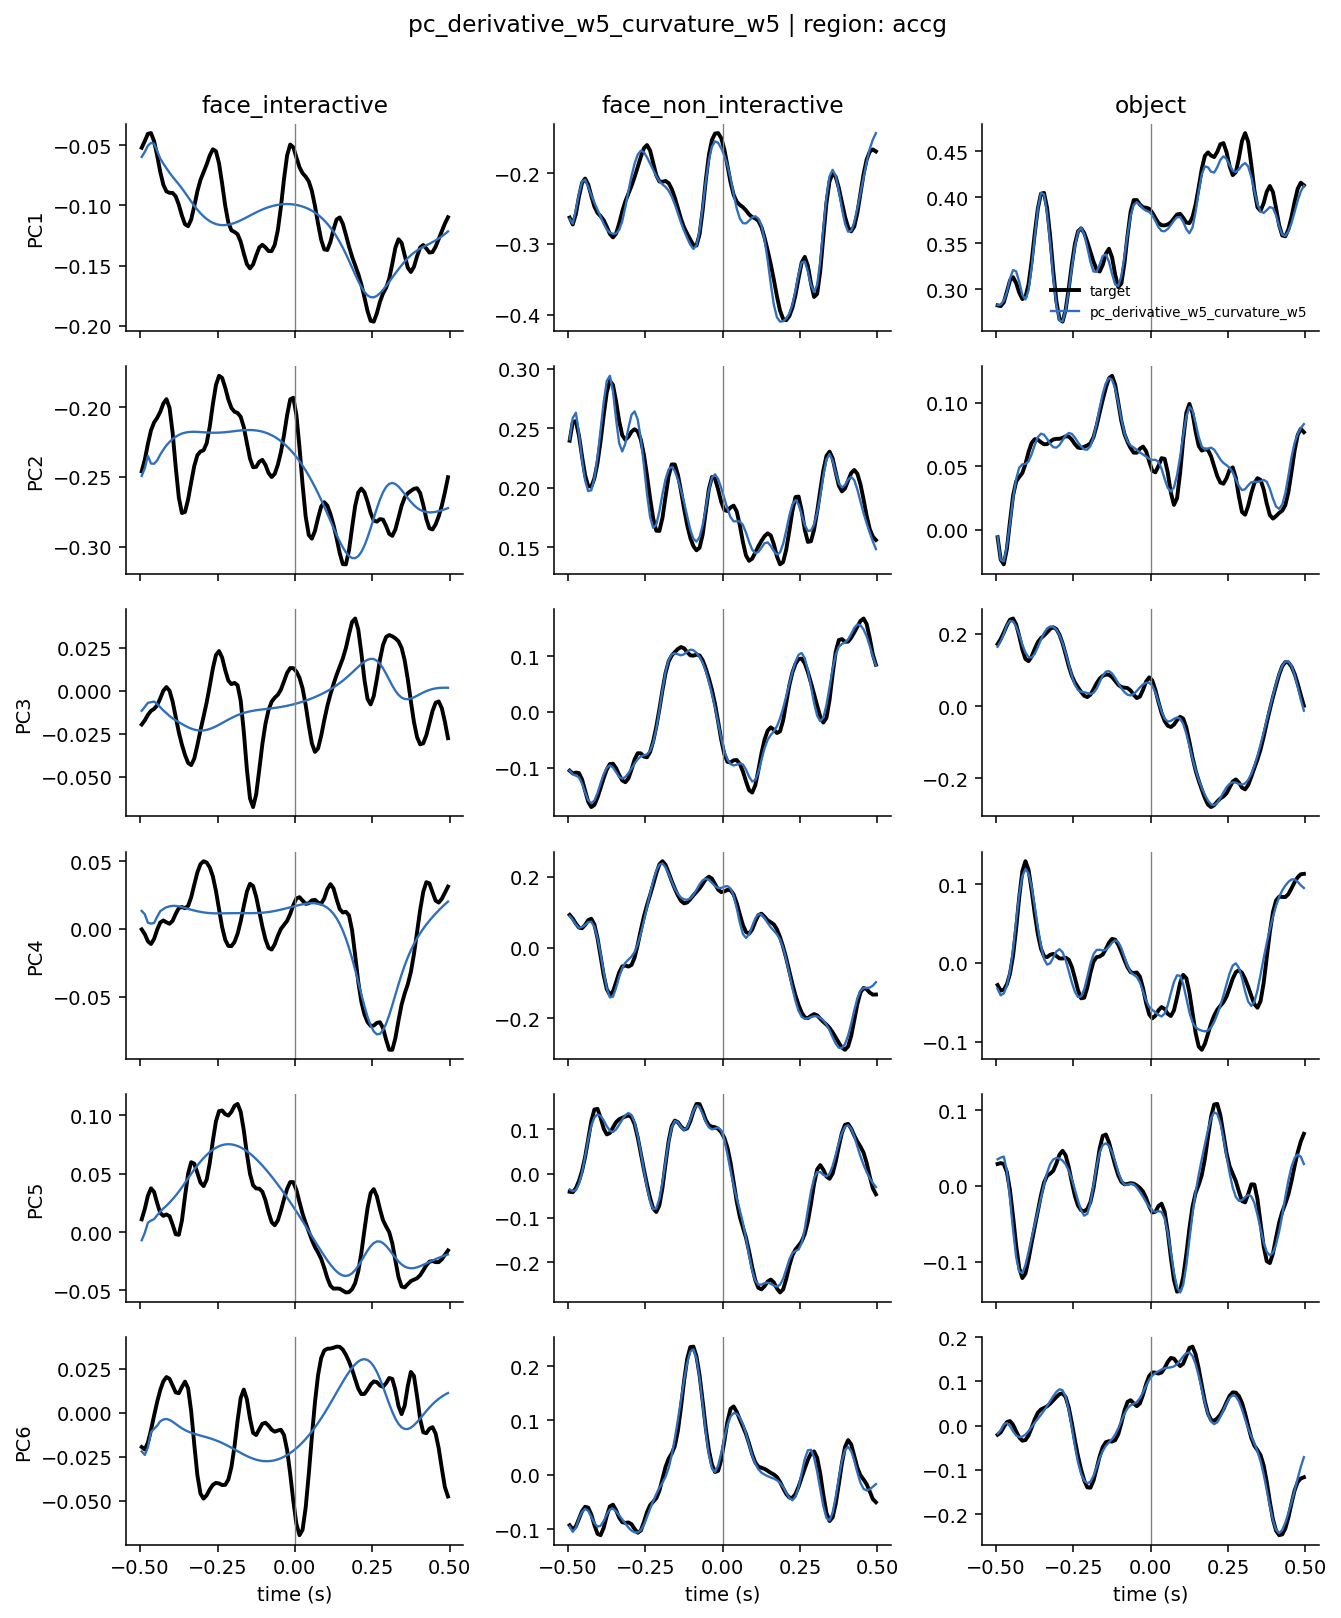

In [17]:
plot_random_region_pc_reconstruction(d5_c5_bundle);

### 5.5 Random-Region Backprojected Firing Rates

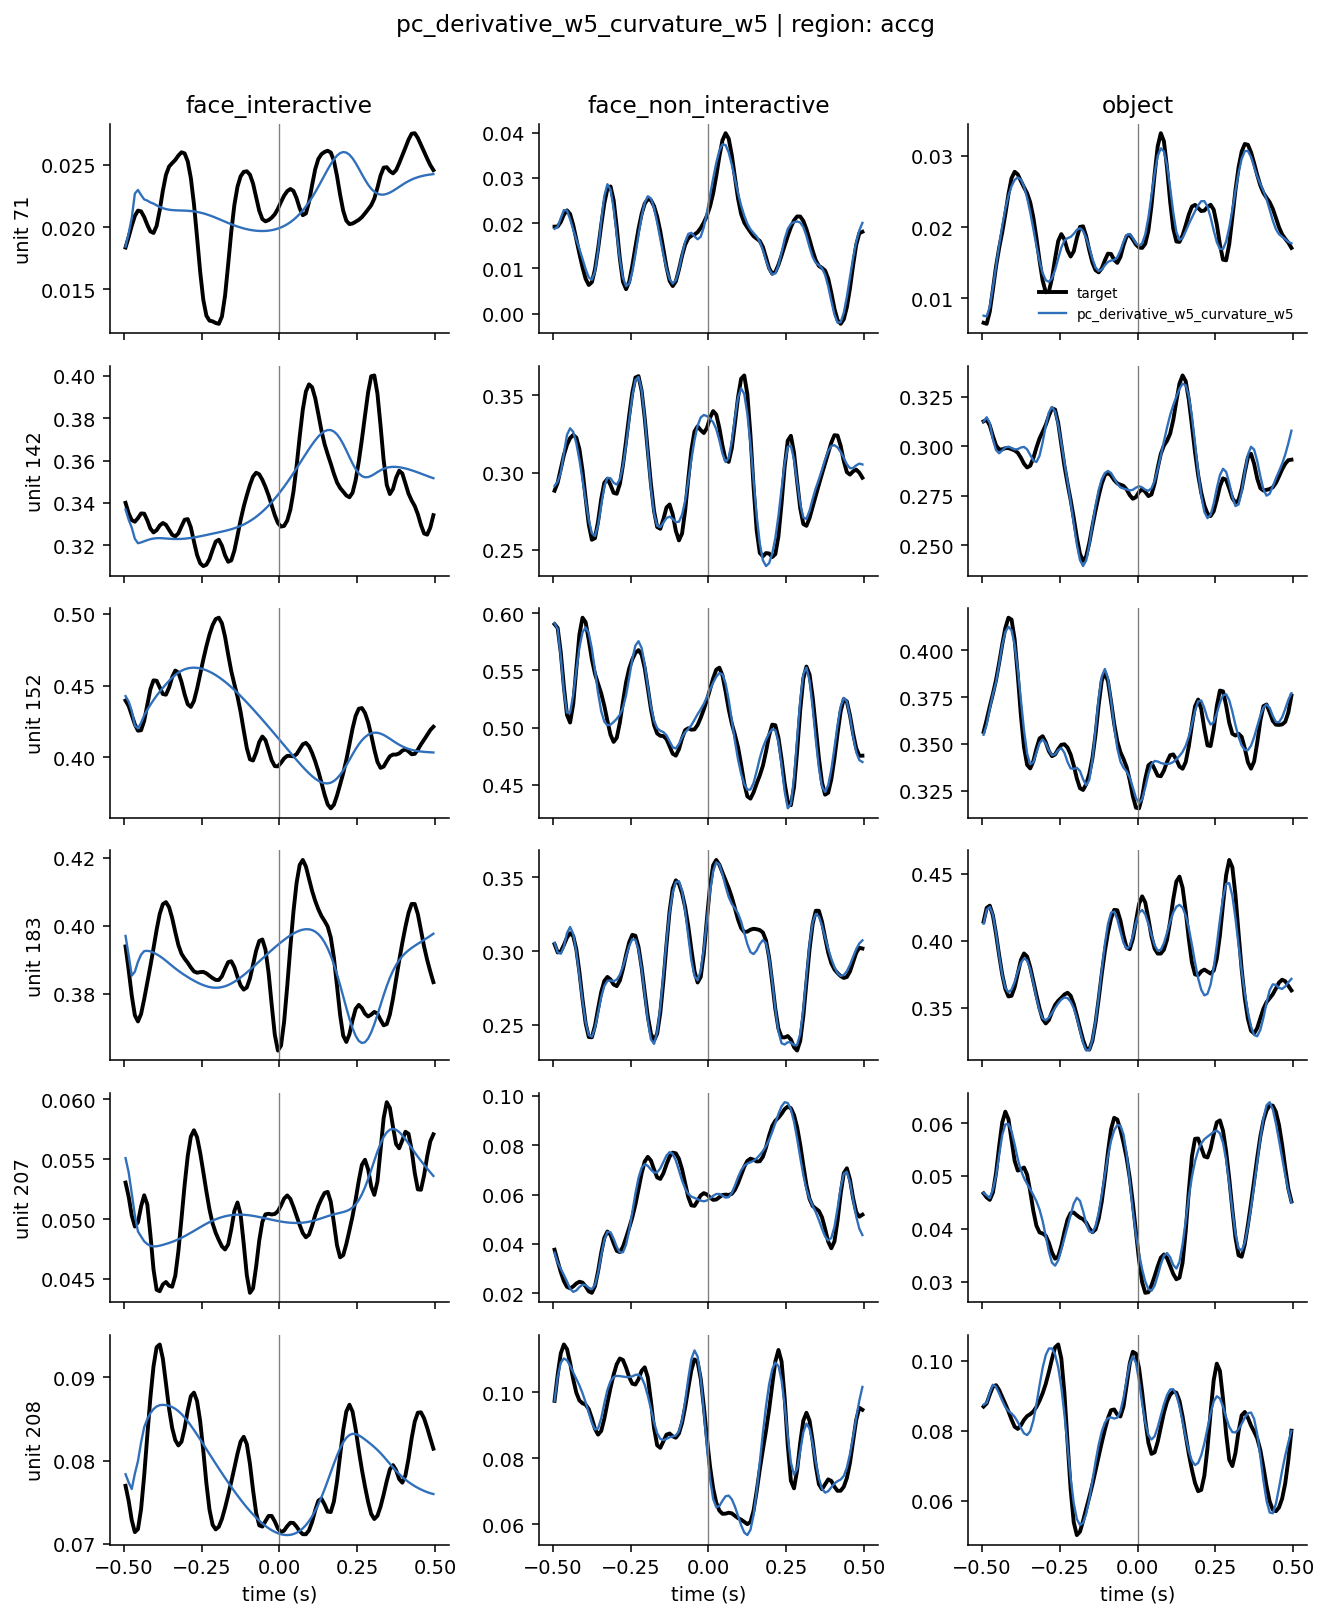

In [18]:
plot_random_region_fr_reconstruction(d5_c5_bundle);